# Feature Combination Sets Interpretability Analysis and Happiness Formula Construction — Logistic Regression (No-Resampling Setting)

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive
import os

drive.mount('/content/drive')
DRIVE_DATA_PATH = "/content/drive/My Drive/WVS_happiness_study"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
X_train = pd.read_csv(f"{DRIVE_DATA_PATH}/data/train_sets/X_train_final_ori.csv")
X_test = pd.read_csv(f"{DRIVE_DATA_PATH}/data/test_sets/X_test_final.csv")
X_val = pd.read_csv(f"{DRIVE_DATA_PATH}/data/val_sets/X_val_final.csv")

y_train = pd.read_csv(f"{DRIVE_DATA_PATH}/data/train_sets/y_train_final_ori.csv")
y_test = pd.read_csv(f"{DRIVE_DATA_PATH}/data/test_sets/y_test_final.csv")
y_val = pd.read_csv(f"{DRIVE_DATA_PATH}/data/val_sets/y_val_final.csv")

In [3]:
feature_sets = {

    "set_1": [
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3",
        "trust3",
        "ethical80",
        "civic53",
        "compassion1",
        "compassion2",
        "compassion3",
        "compassion4",
        "growth16",
        "age",
        "marital_status",
        "religious1",
        "income_scale"
    ],

    "set_2": [
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3",
        "trust3",
        "ethical80",
        "civic53",
        "compassion2",
        "compassion3",
        "growth16",
        "age",
        "marital_status"
    ],

    "set_3": [ # maslow needs only
        "sact",
        "physio1",
        "safety5",
        "belonging1",
        "esteem3"
    ],

    "set_4": [ # maturity of heart only
        "trust3",
        "ethical80",
        "civic53",
        "compassion1",
        "compassion2",
        "growth16"
    ],

    "set_5": [ # hybrid
        "sact",
        "physio1",
        "safety5",
        "trust3",
        "ethical80"
    ],


    "set_6": [ # top 3
        "sact",
        "physio1",
        "safety5"
    ]
}



In [4]:
data_splits = {}

for name, features in feature_sets.items():
    data_splits[name] = {
        "X_train": X_train[features],
        "X_val": X_val[features],
        "X_test": X_test[features],
        "feature_columns": features
    }

In [5]:
model_paths = {}
for name, features in feature_sets.items():
  model_paths[name] = f"{DRIVE_DATA_PATH}/model/no_sampling_logistic/logistic_model_{name}.pkl"

missing_models = {}

for name, path in model_paths.items():
    if os.path.exists(path):
        print(f"[OK] {name}: exists")
    else:
        print(f"[MISSING] {name}: not found")
        missing_models[name] = path

[OK] set_1: exists
[OK] set_2: exists
[OK] set_3: exists
[OK] set_4: exists
[OK] set_5: exists
[OK] set_6: exists


In [6]:
model_paths

{'set_1': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_1.pkl',
 'set_2': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_2.pkl',
 'set_3': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_3.pkl',
 'set_4': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_4.pkl',
 'set_5': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_5.pkl',
 'set_6': '/content/drive/My Drive/WVS_happiness_study/model/no_sampling_logistic/logistic_model_set_6.pkl'}

In [8]:
import sys
sys.path.append(f"{DRIVE_DATA_PATH}/code/my_ml_tools")
import evaluation

Generating SHAP plots for: set_1


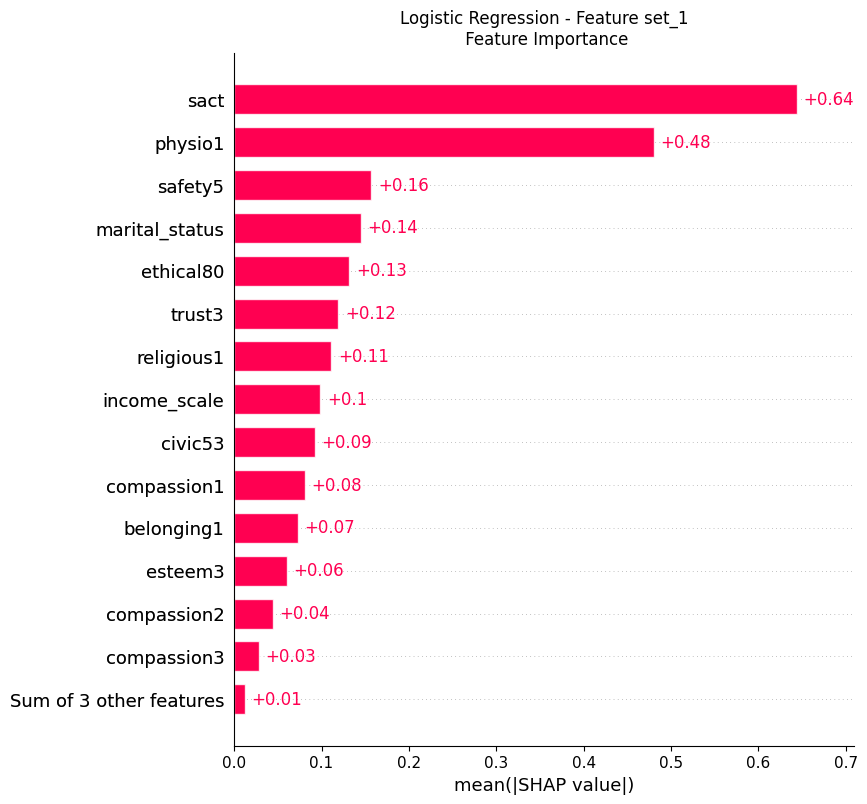

Completed SHAP visualisation for: set_1

Generating SHAP plots for: set_2


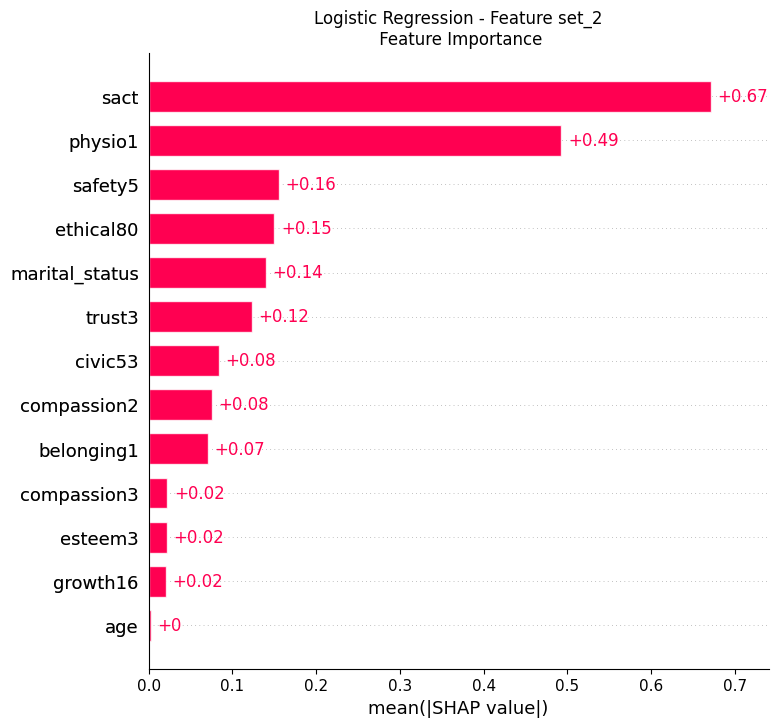

Completed SHAP visualisation for: set_2

Generating SHAP plots for: set_3


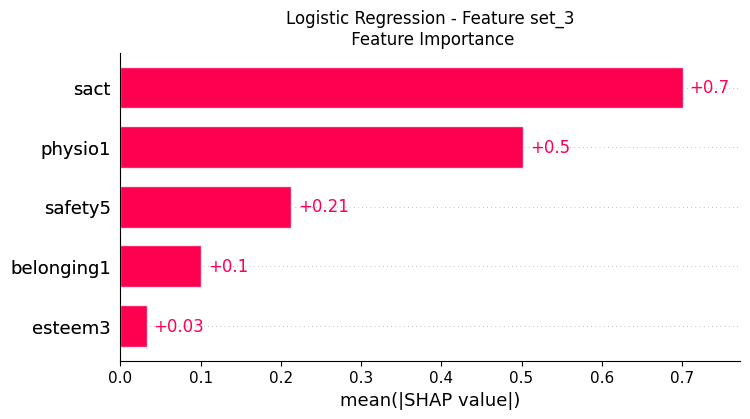

Completed SHAP visualisation for: set_3

Generating SHAP plots for: set_4


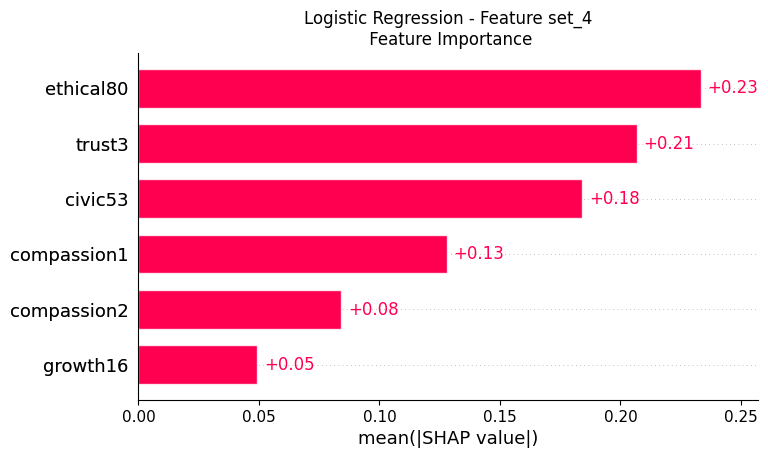

Completed SHAP visualisation for: set_4

Generating SHAP plots for: set_5


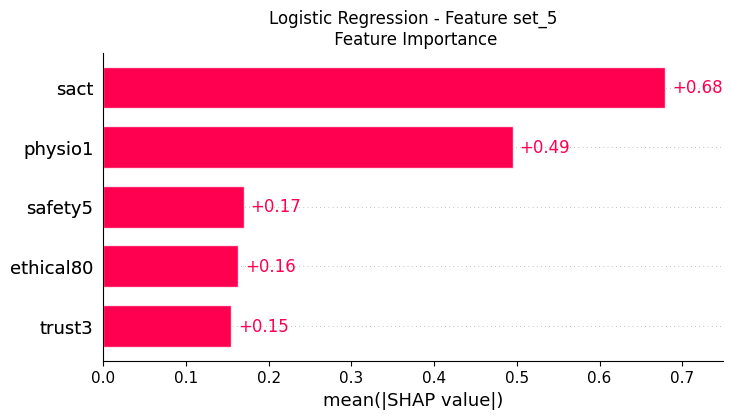

Completed SHAP visualisation for: set_5

Generating SHAP plots for: set_6


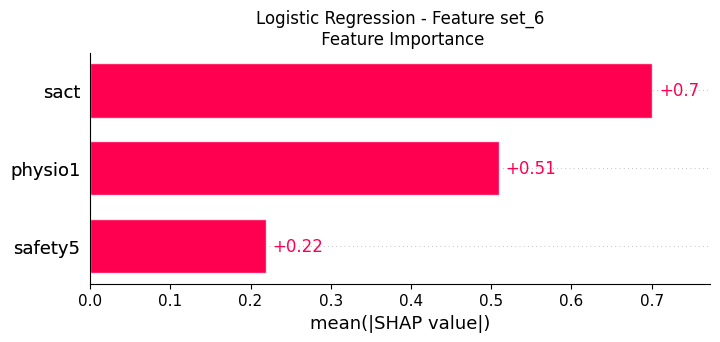

Completed SHAP visualisation for: set_6



In [9]:
OUTPUT_DIR = f"{DRIVE_DATA_PATH}/figures/logistic_shap"
evaluation.visualise_shap(model_paths, data_splits, max_display=15, plots='bar', save_plots=True,output_dir=OUTPUT_DIR)

Absolute Mean Value for Set 5.

In [10]:
import shap
from IPython.display import Markdown
import joblib

set_chosen = 'set_5'

model = joblib.load(model_paths[set_chosen])
set_5_X_test = data_splits[set_chosen]["X_test"]

set_5_explainer = shap.Explainer(model, set_5_X_test)  # assign to an explainer

# Calculate SHAP values
set_5_shap_values = set_5_explainer(set_5_X_test)

In [11]:
import pandas as pd

set_5_shap_weights = evaluation.calculate_shap_weights(set_5_shap_values, data_splits[set_chosen]['feature_columns'])

shap_importance_table = pd.DataFrame({
    "Feature": list(set_5_shap_weights.keys()),
    "Mean |SHAP| weight": list(set_5_shap_weights.values())
})

shap_importance_table


,Feature,Mean |SHAP| weight
0,sact,0.408696
1,physio1,0.297577
2,safety5,0.102290
3,trust3,0.093125
4,ethical80,0.098312


In [12]:
from IPython.display import Markdown
import re

def get_logistic_estimator(fitted_model):
    """Return the estimator that exposes Logistic Regression coefficients."""
    if hasattr(fitted_model, "coef_") and hasattr(fitted_model, "intercept_"):
        return fitted_model

    if hasattr(fitted_model, "named_steps"):
        for step in fitted_model.named_steps.values():
            if hasattr(step, "coef_") and hasattr(step, "intercept_"):
                return step

    raise AttributeError("No coefficient-based estimator was found in the fitted model.")


logistic_estimator = get_logistic_estimator(model)
set_5_features = data_splits[set_chosen]["feature_columns"]

logistic_intercept = float(logistic_estimator.intercept_[0])
logistic_coefficients = dict(zip(set_5_features, logistic_estimator.coef_[0]))

coefficient_table = pd.DataFrame({
    "Feature": list(logistic_coefficients.keys()),
    "Coefficient": list(logistic_coefficients.values())
})
coefficient_table["Direction for class 1"] = coefficient_table["Coefficient"].apply(
    lambda value: "Increases P(y=1)" if value > 0 else "Decreases P(y=1)"
)
coefficient_markdown = "| Feature | Coefficient | Direction for class 1 |\n"
coefficient_markdown += "|---|---:|---|\n"
for _, row in coefficient_table.iterrows():
    coefficient_markdown += (
        f"| {row['Feature']} | {row['Coefficient']:.6f} | "
        f"{row['Direction for class 1']} |\n"
    )

terms = []

for var, coefficient in logistic_coefficients.items():

    match = re.match(r"([a-zA-Z_]+)(\d+)", var)

    if match:
        name, digits = match.groups()
        var_latex = f"{name}_{{{digits}}}"
    else:
        var_latex = var

    sign = "+" if coefficient >= 0 else "-"
    terms.append(f" {sign} {abs(coefficient):.3f} \\cdot {var_latex}")

linear_expr = f"{logistic_intercept:.3f}" + "".join(terms)

logit_latex = f"""
### *Coefficient-Based Logistic Regression Formula for Combination 5*

$$
P(y=1) = \\frac{{1}}{{1 + e^{{-({linear_expr})}}}}
$$

### *Extracted Coefficients*
{coefficient_markdown}

### *Interpretation*
- $P(y=1)$ = predicted probability of class 1 from the fitted Logistic Regression model
- Coefficients are extracted from the trained Combination 5 Logistic Regression model
- SHAP values are used for feature contribution interpretation, not as formula coefficients
- If class 1 represents happiness, this is the happiness probability; if class 1 represents risk, this is the risk probability
"""

Markdown(logit_latex)


### *Coefficient-Based Logistic Regression Formula for Combination 5*

$$
P(y=1) = \frac{1}{1 + e^{-(-6.263 + 0.797 \cdot sact + 0.704 \cdot physio_{1} + 0.285 \cdot safety_{5} + 0.379 \cdot trust_{3} + 0.246 \cdot ethical_{80})}}
$$

### *Extracted Coefficients*
| Feature | Coefficient | Direction for class 1 |
|---|---:|---|
| sact | 0.796652 | Increases P(y=1) |
| physio1 | 0.703860 | Increases P(y=1) |
| safety5 | 0.284829 | Increases P(y=1) |
| trust3 | 0.379410 | Increases P(y=1) |
| ethical80 | 0.246075 | Increases P(y=1) |


### *Interpretation*
- $P(y=1)$ = predicted probability of class 1 from the fitted Logistic Regression model
- Coefficients are extracted from the trained Combination 5 Logistic Regression model
- SHAP values are used for feature contribution interpretation, not as formula coefficients
- If class 1 represents happiness, this is the happiness probability; if class 1 represents risk, this is the risk probability


## Statistical Testing for the Combination 5 Happiness Formula

This section provides inferential support for the five predictors used in the practical happiness formula. SHAP is used for interpretability, while statistical testing is performed using a logistic regression inference model on the selected Combination 5 predictors.

**Feature-level test:** Wald test

- $H_0: \beta_i = 0$; the predictor has no statistically significant relationship with happiness.
- $H_1: \beta_i \neq 0$; the predictor has a statistically significant relationship with happiness.

**Model-level test:** Likelihood Ratio Test

- $H_0: \beta_1 = \beta_2 = ... = \beta_n = 0$; the five predictors do not improve model fit over the intercept-only model.
- $H_1:$ at least one predictor improves model fit.

A significance level of $\alpha = 0.05$ is used. The coefficient-based formula above is extracted from the trained scikit-learn Logistic Regression model; the statistical testing below refits an equivalent logistic inference model using `statsmodels` so that p-values, confidence intervals, odds ratios, and likelihood-ratio statistics can be reported.

In [13]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import chi2

alpha = 0.05

# Use the selected practical feature set from Combination 5.
X_train_set_5 = data_splits[set_chosen]["X_train"].copy()
y_train_series = pd.Series(np.ravel(y_train), name="happy")

# Add intercept for inferential logistic regression.
X_train_set_5_const = sm.add_constant(X_train_set_5, has_constant="add")

# GLM with Binomial family gives logistic regression inference output.
glm_full = sm.GLM(y_train_series, X_train_set_5_const, family=sm.families.Binomial()).fit()

# Intercept-only model for likelihood-ratio testing.
X_train_null = pd.DataFrame({"const": np.ones(len(y_train_series))})
glm_null = sm.GLM(y_train_series, X_train_null, family=sm.families.Binomial()).fit()

glm_full.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                  happy   No. Observations:                66418
Model:                            GLM   Df Residuals:                    66412
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -20917.
Date:                Sat, 27 Jun 2026   Deviance:                       41834.
Time:                        13:59:26   Pearson chi2:                 6.56e+04
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1760
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.2648      0.099    -63.227      0.000      -6.459      -6.071
sact           0.7968      0.012     67.387      0.000       0.774       0.820
physio1        0.7039      0.015     47.692      0.000       0.675       0.733
safety5        0.2849      0.016     18.339      0.000       0.254       0.315
trust3         0.3796      0.019     19.748      0.000       0.342       0.417
ethical80      0.2462      0.015     16.276      0.000       0.217       0.276
==============================================================================
"""

In [14]:
# Wald tests for individual coefficients.
conf_int = glm_full.conf_int()
wald_results = pd.DataFrame({
    "Predictor": glm_full.params.index,
    "Coefficient": glm_full.params.values,
    "Std. Error": glm_full.bse.values,
    "z-value": glm_full.tvalues.values,
    "p-value": glm_full.pvalues.values,
    "Odds Ratio": np.exp(glm_full.params.values),
    "OR 95% CI Lower": np.exp(conf_int[0].values),
    "OR 95% CI Upper": np.exp(conf_int[1].values),
})

wald_results["Decision"] = np.where(
    wald_results["p-value"] < alpha,
    "Reject H0",
    "Fail to reject H0"
)

wald_results["Interpretation"] = np.where(
    wald_results["Predictor"] == "const",
    "Intercept",
    np.where(
        wald_results["p-value"] < alpha,
        "Statistically significant predictor",
        "Not statistically significant at alpha = 0.05"
    )
)

wald_results.round(6)


,Predictor,Coefficient,Std. Error,z-value,p-value,Odds Ratio,OR 95% CI Lower,OR 95% CI Upper,Decision,Interpretation
0,const,-6.264780,0.099083,-63.227367,0.0,0.001902,0.001566,0.002310,Reject H0,Intercept
1,sact,0.796809,0.011824,67.386621,0.0,2.218451,2.167629,2.270466,Reject H0,Statistically significant predictor
2,physio1,0.703911,0.014760,47.691933,0.0,2.021644,1.963999,2.080980,Reject H0,Statistically significant predictor
3,safety5,0.284920,0.015536,18.339183,0.0,1.329655,1.289777,1.370766,Reject H0,Statistically significant predictor
4,trust3,0.379633,0.019224,19.748003,0.0,1.461748,1.407697,1.517874,Reject H0,Statistically significant predictor
5,ethical80,0.246188,0.015126,16.275733,0.0,1.279140,1.241775,1.317630,Reject H0,Statistically significant predictor


In [15]:
# Likelihood Ratio Test for the full Combination 5 model against an intercept-only model.
lr_stat = 2 * (glm_full.llf - glm_null.llf)
lr_df = int(glm_full.df_model - glm_null.df_model)
lr_p_value = chi2.sf(lr_stat, lr_df)

lr_test_results = pd.DataFrame({
    "Test": ["Likelihood Ratio Test"],
    "Null Model": ["Intercept only"],
    "Full Model": ["Combination 5 predictors"],
    "LR Statistic": [lr_stat],
    "df": [lr_df],
    "p-value": [lr_p_value],
    "Decision": ["Reject H0" if lr_p_value < alpha else "Fail to reject H0"],
    "Interpretation": [
        "Combination 5 significantly improves model fit"
        if lr_p_value < alpha
        else "Combination 5 does not significantly improve model fit"
    ]
})

lr_test_results.round(6)


,Test,Null Model,Full Model,LR Statistic,df,p-value,Decision,Interpretation
0,Likelihood Ratio Test,Intercept only,Combination 5 predictors,12861.426748,5,0.0,Reject H0,Combination 5 significantly improves model fit


### Reporting Guidance

Use the Wald test table to discuss whether each individual predictor significantly contributes to the probability of happiness. Use the likelihood-ratio test to determine whether Combination 5, as a full hybrid feature set, significantly improves model fit compared with an intercept-only model.

Suggested wording:

> The Wald test was used to evaluate the statistical significance of each predictor in the Combination 5 logistic model. The likelihood-ratio test was then applied to compare the full model against an intercept-only model. This allowed the study to assess both feature-level and model-level statistical support for the proposed happiness formulation.

## Example Case Testing for the Happiness Formula

The following three example cases demonstrate how the coefficient-based happiness formula can be applied in practice. The cases use the valid ordinal ranges of the five Combination 5 predictors:

- `sact`: 1 to 10
- `physio1`: 1 to 5
- `safety5`: 1 to 4
- `trust3`: 1 to 4
- `ethical80`: 1 to 4

The formula first calculates the predicted probability of happiness, $P(happiness=1)$. Happiness risk is then calculated as the complement:

$$
Risk = 1 - P(happiness=1)
$$

In [16]:
for col in X_train_set_5:
    print(col, ":",X_train_set_5[col].unique())

sact : [1. 3. 5. 4. 2.]
physio1 : [3. 5. 4. 2. 1.]
safety5 : [2. 4. 3. 1.]
trust3 : [2. 4. 3. 1.]
ethical80 : [1. 2. 3. 4.]


In [17]:
example_cases = pd.DataFrame([
    {
        "Case": "Low scores",
        "sact": 1,
        "physio1": 1,
        "safety5": 1,
        "trust3": 1,
        "ethical80": 1,
    },
    {
        "Case": "Moderate scores",
        "sact": 3,
        "physio1": 3,
        "safety5": 3,
        "trust3": 3,
        "ethical80": 3,
    },
    {
        "Case": "High scores",
        "sact": 5,
        "physio1": 5,
        "safety5": 4,
        "trust3": 4,
        "ethical80": 4,
    },
])

def sigmoid(value):
    return 1 / (1 + np.exp(-value))

def classify_happiness_probability(probability):
    if probability < 0.50:
        return "Low predicted happiness"
    if probability < 0.75:
        return "Moderate predicted happiness"
    if probability < 0.90:
        return "High predicted happiness"
    return "Very high predicted happiness"

# Use the exact fitted Logistic Regression intercept and coefficients extracted earlier.
feature_columns = list(logistic_coefficients.keys())
example_cases["z-score"] = logistic_intercept + example_cases[feature_columns].mul(
    pd.Series(logistic_coefficients)
).sum(axis=1)
example_cases["P(happiness=1)"] = sigmoid(example_cases["z-score"])
example_cases["Happiness risk"] = 1 - example_cases["P(happiness=1)"]
example_cases["Interpretation"] = example_cases["P(happiness=1)"].apply(
    classify_happiness_probability
)

example_case_results = example_cases.copy()
example_case_results[[
    "z-score",
    "P(happiness=1)",
    "Happiness risk"
]] = example_case_results[[
    "z-score",
    "P(happiness=1)",
    "Happiness risk"
]].round(6)

example_case_results


,Case,sact,physio1,safety5,trust3,ethical80,z-score,P(happiness=1),Happiness risk,Interpretation
0,Low scores,1,1,1,1,1,-3.851944,0.020797,0.979203,Low predicted happiness
1,Moderate scores,3,3,3,3,3,0.969707,0.725061,0.274939,Moderate predicted happiness
2,High scores,5,5,4,4,4,4.881045,0.992468,0.007532,Very high predicted happiness
